In [1]:
model_name = "vit-ragdoll"


import iree
import iree.compiler
import iree.runtime
import torch
import numpy as np
from torch import nn
from torchvision import models

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll

def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=33):
    return ti(stmt, globals=globals(), number=n) * 1000 / n



BENCHMARK_REPEAT=33
df = pd.DataFrame()

def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo

In [17]:
model_file = "vit.mlir"
target_file = model_file + ".demo"
!ragdoll-opt {model_file}  \
--canonicalize \
--enable-cse-in-legalizer \
--symbol-dce \
--ragdoll-autodiff-vjp-public-functions='strategy=heuristic' \
--ragdoll-autodiff-vjp \
 > {target_file}
!ragdoll-opt {target_file} -pass-pipeline="builtin.module(func.func(tosa-to-linalg-named,linalg-generalize-named-ops,linalg-fuse-elementwise-ops))"

#map = affine_map<(d0, d1, d2, d3) -> (d0, d1, d2, d3)>
#map1 = affine_map<(d0, d1, d2, d3, d4, d5, d6) -> (d0, d1 * 16 + d4, d2 * 16 + d5, d6)>
#map2 = affine_map<(d0, d1, d2, d3, d4, d5, d6) -> (d3, d4, d5, d6)>
#map3 = affine_map<(d0, d1, d2, d3, d4, d5, d6) -> (d0, d1, d2, d3)>
#map4 = affine_map<(d0, d1, d2) -> (d0, d1, d2)>
#map5 = affine_map<(d0, d1, d2, d3) -> (d0, d1, d3)>
#map6 = affine_map<(d0, d1, d2, d3) -> (d0, d1, d2)>
#map7 = affine_map<(d0, d1, d2, d3) -> (d0, d2, d1, d3)>
#map8 = affine_map<(d0, d1, d2, d3) -> (d0, d2, d3)>
#map9 = affine_map<(d0, d1, d2, d3) -> (d0, d3, d2)>
#map10 = affine_map<(d0, d1, d2, d3) -> (d0, d3, d1)>
#map11 = affine_map<(d0, d1, d2) -> (d0, d2, d1)>
module {
  ml_program.global private mutable @global136 : tensor<1x197x1xf32>
  ml_program.global private mutable @global135 : tensor<1x197x1xf32>
  ml_program.global private mutable @global134 : tensor<1x197x768xf32>
  ml_program.global private mutable @global133 : tensor<1x197x3072xf32>
  ml_

In [2]:
model_file_base = "vit.mlir"
bs=4
model_file = model_file_base + ".bs{}".format(bs)
target_file = model_file + ".heuristic.clean"
!ragdoll-opt {model_file}  \
--canonicalize \
--enable-cse-in-legalizer \
--symbol-dce \
--ragdoll-autodiff-vjp-public-functions='strategy=heuristic' \
--ragdoll-autodiff-vjp \
--inline \
--ragdoll-autodiff-inline-function-call \
--ragdoll-initialisation \
--eliminate-empty-tensors \
--ragdoll-legalise-to-iree-compatibility \
--ragdoll-raise-linalg-to-tosa \
--canonicalize \
--cse > {target_file}

In [3]:
model_file = "vit.mlir"
bs=4
#bs=1
source_file = model_file + ".bs{}.heuristic.clean".format(bs)
target_file = source_file + ".vmfb"
print("compiling {} to {}".format(source_file, target_file))
!iree-compile {source_file} \
-o {target_file} \
--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0 \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
--iree-hal-cuda-llvm-target-arch=sm_86

compiling vit.mlir.bs4.heuristic.clean to vit.mlir.bs4.heuristic.clean.vmfb


In [4]:
import gc
model_file = "vit.mlir"
for bs in [4]:
    source_file = model_file + ".bs{}.heuristic.clean".format(bs)
    target_file = source_file + ".vmfb"
    print("compiling {} to {}".format(source_file, target_file))
    #!iree-compile {source_file} \
    #-o {target_file} \
    #--iree-hal-target-backends=cuda \
    #--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
    #--iree-hal-cuda-llvm-target-arch=sm_86

    ragdoll_binary = load_executable(target_file)

    image = torch.randn(bs, 3, 224, 224)
    image_np = image.detach().cpu().numpy()
    image_t = torch.randn(bs, 224, 224, 3)
    image_np_t = image_t.detach().cpu().numpy()
    model = models.vit_b_16().train(False)
    model.load_state_dict({k: torch.ones_like(v) * 0.23421 for k, v in model.state_dict().items()})
    output = model(image)
    grad = torch.randn_like(output)
    grad_np = grad.cpu().numpy()

    try:
        f1 = timeit("ragdoll_binary.forward(image_np_t)") / BENCHMARK_REPEAT
        print('ragdoll-opt1-gpu-forward in timeit: ', f1)
        b1 = timeit("ragdoll_binary.dforward(grad_np)") / BENCHMARK_REPEAT
        print('ragdoll-opt1-gpu-forward in timeit: ', b1)
        df = pd.concat([df, get_dataframe(f1, b1, "Ragdoll-Autodiff at batch-size = {}".format(bs))])
    except Exception as e:
        print(f"处理模型时出错，批量大小 {bs}: {e}")
    print(df)

compiling vit.mlir.bs4.heuristic.clean to vit.mlir.bs4.heuristic.clean.vmfb
ragdoll-opt1-gpu-forward in timeit:  18.373783079170106
ragdoll-opt1-gpu-forward in timeit:  28.147511905156712
        time      pass                                item
0  18.373783   Forward  Ragdoll-Autodiff at batch-size = 4
0  28.147512  Backward  Ragdoll-Autodiff at batch-size = 4
0  46.521295      Full  Ragdoll-Autodiff at batch-size = 4


In [5]:
import gc
model_file = "vit.mlir"
for bs in [4]:
    source_file = model_file + ".bs{}.heuristic".format(bs)
    target_file = source_file + ".vmfb"
    print("compiling {} to {}".format(source_file, target_file))
    #!iree-compile {source_file} \
    #-o {target_file} \
    #--iree-hal-target-backends=cuda \
    #--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
    #--iree-hal-cuda-llvm-target-arch=sm_86

    ragdoll_binary = load_executable(target_file)

    image = torch.randn(bs, 3, 224, 224)
    image_np = image.detach().cpu().numpy()
    image_t = torch.randn(bs, 224, 224, 3)
    image_np_t = image_t.detach().cpu().numpy()
    model = models.vit_b_16().train(False)
    model.load_state_dict({k: torch.ones_like(v) * 0.23421 for k, v in model.state_dict().items()})
    output = model(image)
    grad = torch.randn_like(output)
    grad_np = grad.cpu().numpy()

    try:
        f1 = timeit("ragdoll_binary.forward(image_np_t)") / BENCHMARK_REPEAT
        print('ragdoll-opt1-gpu-forward in timeit: ', f1)
        b1 = timeit("ragdoll_binary.dforward(grad_np)") / BENCHMARK_REPEAT
        print('ragdoll-opt1-gpu-forward in timeit: ', b1)
        df = pd.concat([df, get_dataframe(f1, b1, "Ragdoll-Autodiff at batch-size = {}".format(bs))])
    except Exception as e:
        print(f"处理模型时出错，批量大小 {bs}: {e}")
    print(df)

compiling vit.mlir.bs4.heuristic to vit.mlir.bs4.heuristic.vmfb
ragdoll-opt1-gpu-forward in timeit:  18.266288579858095
ragdoll-opt1-gpu-forward in timeit:  28.227239524769445
        time      pass                                item
0  18.373783   Forward  Ragdoll-Autodiff at batch-size = 4
0  28.147512  Backward  Ragdoll-Autodiff at batch-size = 4
0  46.521295      Full  Ragdoll-Autodiff at batch-size = 4
0  18.266289   Forward  Ragdoll-Autodiff at batch-size = 4
0  28.227240  Backward  Ragdoll-Autodiff at batch-size = 4
0  46.493528      Full  Ragdoll-Autodiff at batch-size = 4


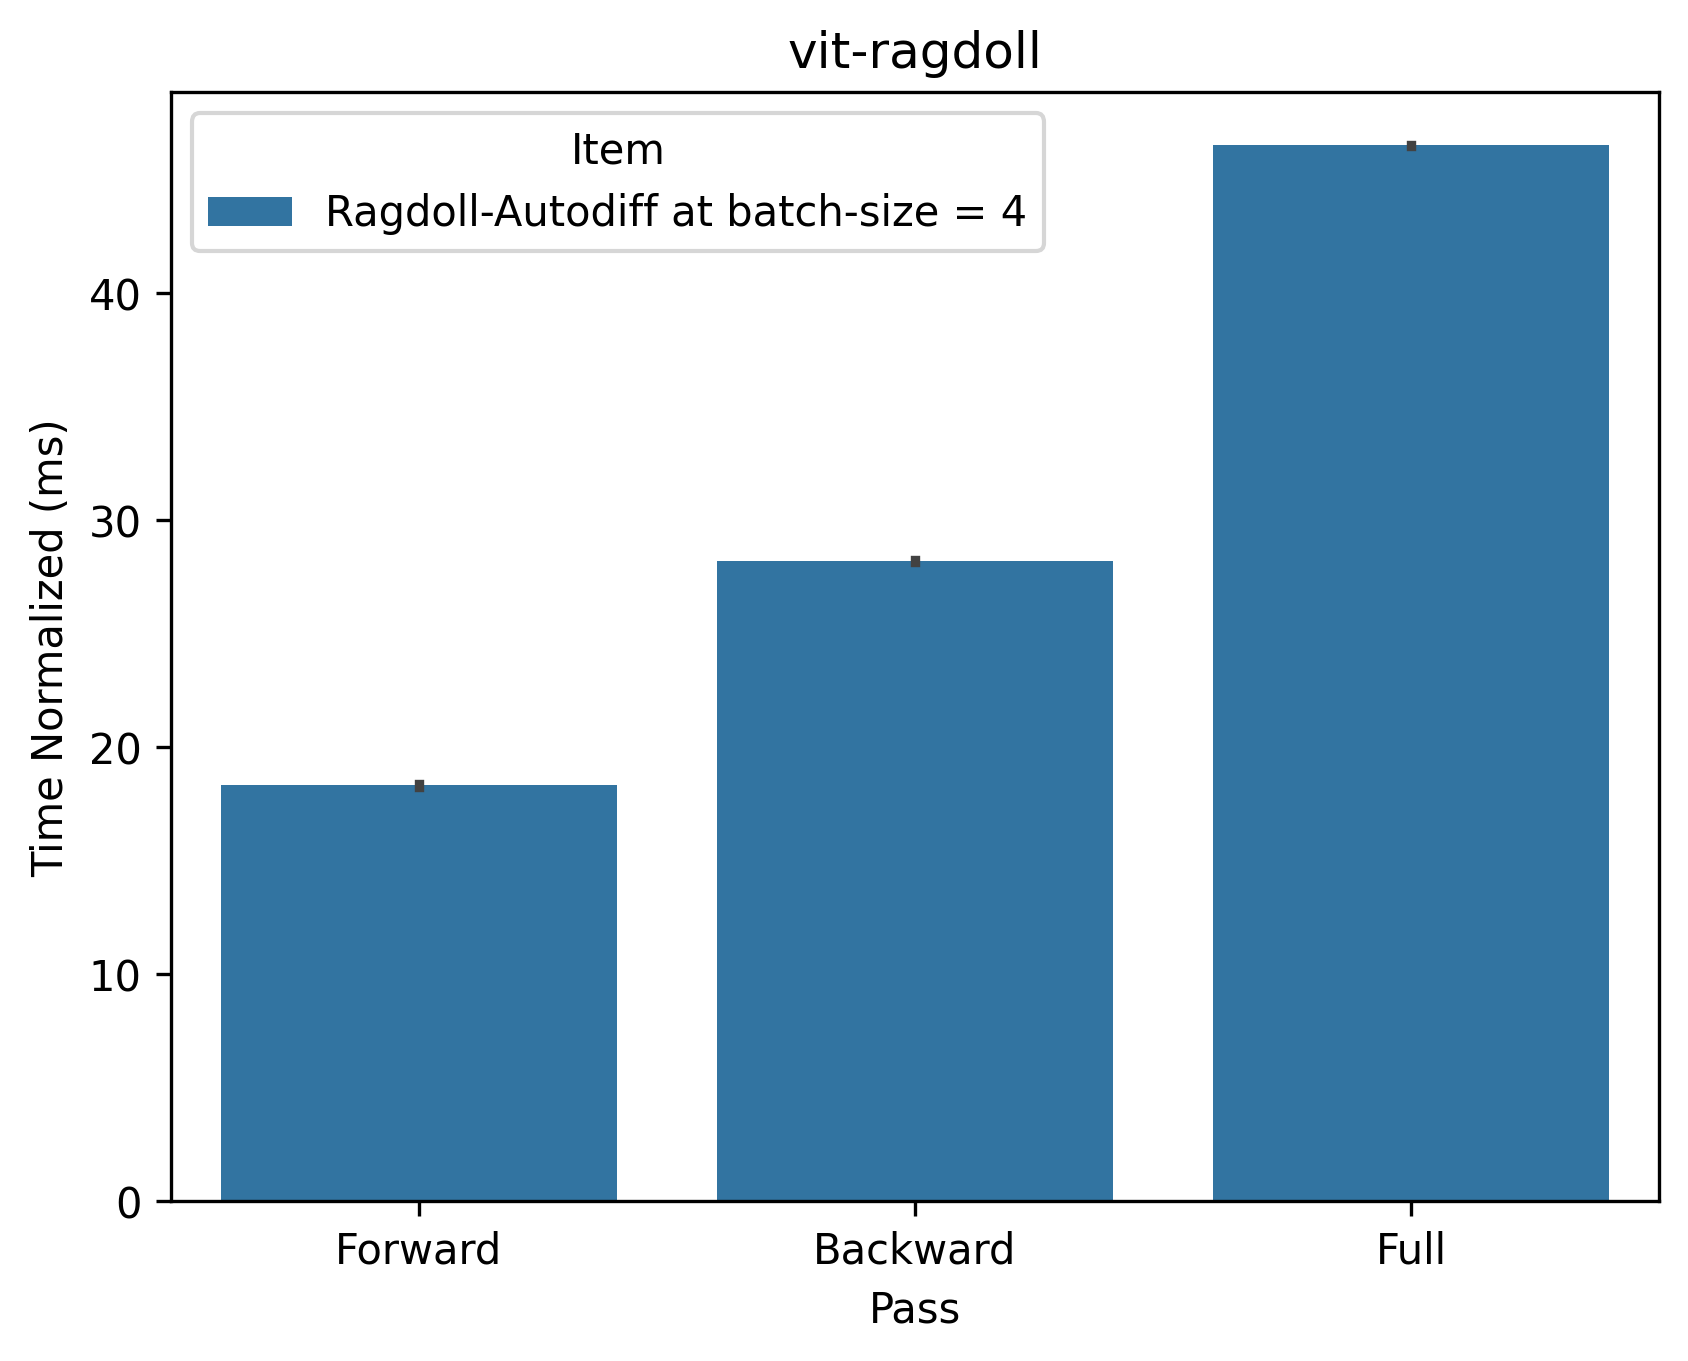

In [6]:
df.style.hide(axis="index")
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")